In [1]:
using Pkg
Pkg.activate("../project")
using DrWatson
@quickactivate "project"

using StableRNGs
using Distributions
using ConcurrentSim
using ResumableFunctions
using DataFrames
using Plots
using CSV

include(srcdir("mmc_logic.jl"))

#set simulation parameters
rng = StableRNG(123)
num_customers = 500 # total number of customers generated

  Activating new project at `~/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation--modeling/labs/lab07/project/notebooks/project`
  Activating project at `~/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation--modeling/labs/lab07/project`


500

set queue parameters

In [2]:
num_servers = 2 # number of servers
mu = 1.0 / 2 # service rate
lam = 0.9 # arrival rate
arrival_dist = Exponential(1 / lam) # interarrival time distribution
service_dist = Exponential(1 / mu) # service time distribution

Exponential{Float64}(θ=2.0)

Контейнер для сбора статистики (необходим для графиков)

In [3]:
times_data = DataFrame(id = Int[], arrival = Float64[], wait = Float64[])

Row,id,arrival,wait
,Int64,Float64,Float64


setup and run simulation

In [4]:
function setup_and_run()
    sim = Simulation() # initialize simulation environment
    server = Resource(sim, num_servers) # initialize servers
    arrival_time = 0.0
    for i = 1:num_customers # initialize customers
        arrival_time += rand(rng, arrival_dist)
        @process customer(sim, server, i, arrival_time, service_dist, rng, times_data)
    end
    run(sim) # run simulation
end

setup_and_run (generic function with 1 method)

Выполнение симуляции

In [5]:
setup_and_run()

CSV.write(datadir("sim_results_mmc.csv"), times_data)

"/home/nikita/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation--modeling/labs/lab07/project/data/sim_results_mmc.csv"

Распределение времени ожидания

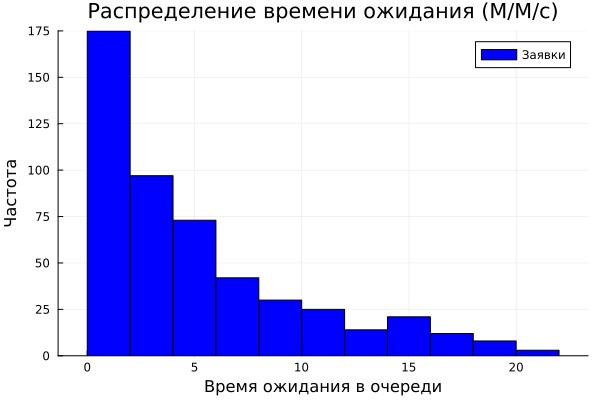

In [6]:
p1 = histogram(times_data.wait,
               title = "Распределение времени ожидания (M/M/c)",
               xlabel = "Время ожидания в очереди",
               ylabel = "Частота",
               label = "Заявки",
               color = :blue,
               fmt = :png
               )

Динамика прибытия событий

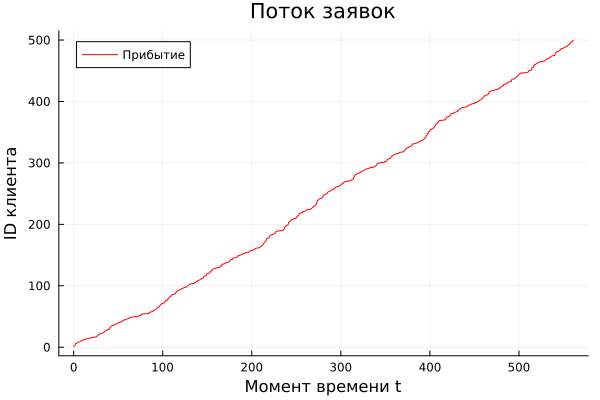

In [7]:
p2 = plot(times_data.arrival, times_data.id,
               title = "Поток заявок",
               xlabel = "Момент времени t",
               ylabel = "ID клиента",
               label = "Прибытие",
               color = :red,
               fmt = :png
               )

Объединение и сохранение графиков

In [8]:
final_plot = plot(p1, p2, layout = (2, 1), size = (800, 600))
savefig(plotsdir("mmc_analysis.png"))

println("Моделирование завершено. Графики сохранены в plots/, данные в data/.")

Моделирование завершено. Графики сохранены в plots/, данные в data/.
